In [25]:
import numpy as np
import matplotlib.pyplot as plt

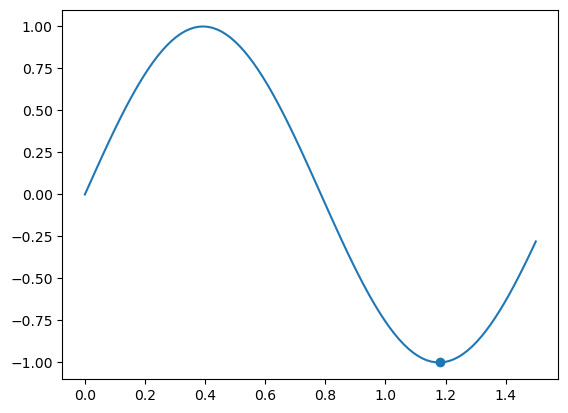

In [26]:
def f(x):
    return np.sin(4 * x)

def generate_training_data(N, sigma, domain):
    X_train = np.random.uniform(*domain, N)
    Y_true = f(X_train)
    Y_train = Y_true + np.random.normal(0, np.sqrt(sigma), N)
    return X_train[:, None], Y_train[:, None]

def generate_score(X, sigma):
    X = np.array(X).ravel()
    Y = np.array(f(X)).ravel()
    return X[:, None], Y[:, None] 

beta = 10
X_min = 0
X_max = 1.5
X_domain = (X_min, X_max)
N_test = 100
X_space = np.linspace(*X_domain, N_test)
Y_best = np.min(f(X_space))
Y_best_idx = np.argmin(f(X_space))
X_best = X_space[Y_best_idx]

plt.plot(X_space, f(X_space))
plt.scatter(X_best, Y_best)
plt.show()

In [27]:
def rbf(x1, x2, l=1.):
    return np.exp(0.5 * np.linalg.norm(x1 - x2)**2 / l**2)

def matern52_kernel(x1, x2, length_scale=1.0, variance=1.0):
    r = np.sqrt(np.sum(((x1 - x2) / length_scale) ** 2))
    kernel_value = variance * (1 + np.sqrt(5) * r + 5/3 * r**2) * np.exp(-np.sqrt(5) * r)
    return kernel_value


In [28]:
def Gram(X, kernel, *kernel_params):
    N = X.shape[0]
    K = np.zeros((N, N))
    for n in range(N):
        for m in range(n+1):
            k = kernel(X[n], X[m], *kernel_params)
            K[n, m] = k
            K[m, n] = k
            
    return K

In [29]:
def GP(X, domain, kernel, *kernel_params, N_test = 100):
    K = Gram(X, kernel, *kernel_params)
    N_train = X.shape[0]
    C = K + np.eye(K.shape[0]) * (1/beta)
    C_inv = np.linalg.inv(C)
    X_test = np.linspace(*domain, N_test)
    K_star = np.zeros((N_test, N_train))
    Y = f(X)
    
    for n in range(N_test):
        for m in range(N_train):
            K_star[n, m] = kernel(X_test[n], X[m])

    K_star_star = Gram(X_test, kernel)
    Mu = K_star.dot(C_inv).dot(Y).ravel()
    Sigma = K_star_star - K_star.dot(C_inv).dot(K_star.T)

    return Mu, Sigma

In [30]:
max_iter = 10
X = np.zeros((max_iter))
Y = np.zeros((max_iter))
X[0] = np.random.uniform(*X_domain)

for i in range(1, max_iter):
    Mu, Sigma = GP(X[:i], X_domain, matern52_kernel)

    sample = np.random.multivariate_normal(Mu, Sigma) # sampled from surrogate

    X_new = X_space[np.argmin(sample)] # simples acquisition function possible
    Y[i] = np.min(sample)
    X[i] = X_new


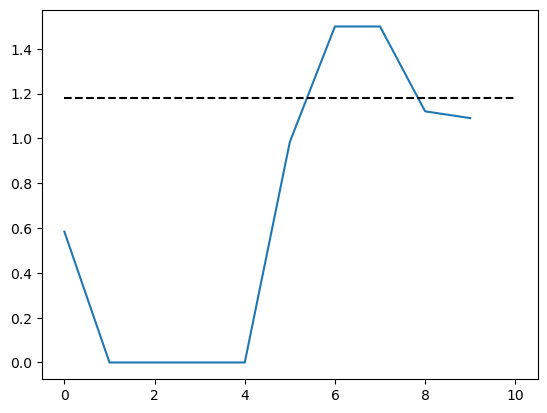

In [31]:
plt.plot(X, label="X values tried")
plt.hlines(X_best, 0, max_iter, ls="--", color="black")

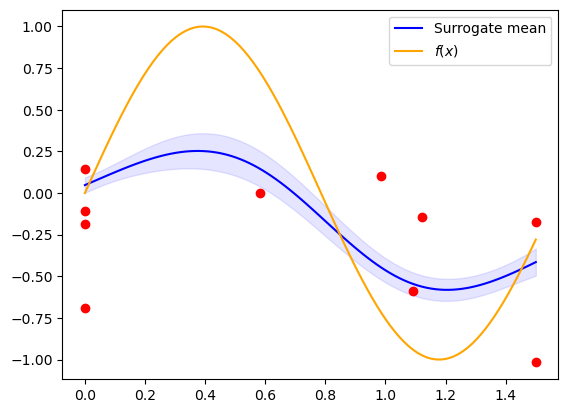

In [32]:
plt.plot(X_space, Mu, color='blue', label="Surrogate mean")
plt.fill_between(X_space, Mu - 1.96 * np.diag(Sigma), Mu + 1.96 * np.diag(Sigma), alpha=0.1, color='blue')
plt.plot(X_space, f(X_space), color="orange", label="$f(x)$")
plt.scatter(X, Y, color = "red", )  
plt.legend()
plt.show()